Initializing environment...
Loading datasets...
Cleaning text for TF-IDF...


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\felic\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\felic\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\felic\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\felic\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Cleaning text for Word2Vec...
Cleaning text for Sentence Transformers...

Generating Word Frequency Bar Charts...


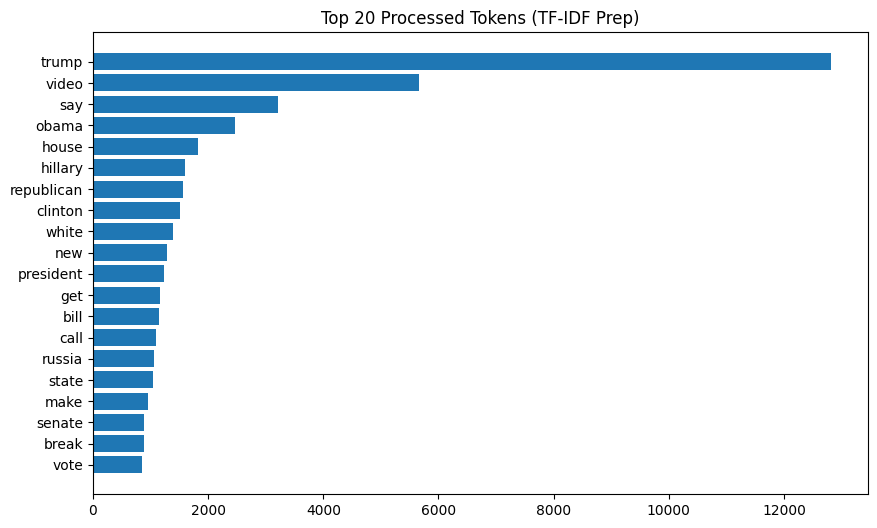


 MODEL 1: TF-IDF + LinearSVC
TF-IDF Estimated Accuracy: 93.78%
TF-IDF Estimated F1 Score: 93.78%


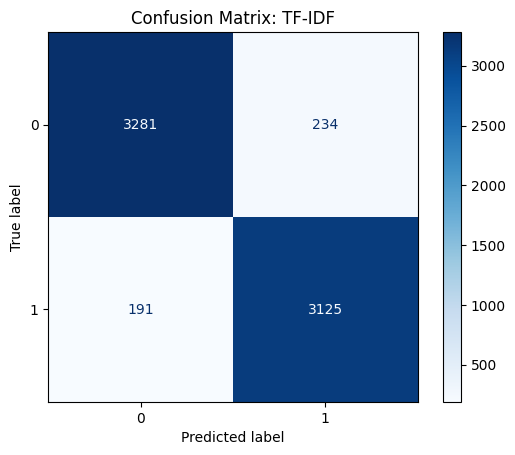

Generating final TF-IDF predictions...

 MODEL 2: Word2Vec + LinearSVC
Word2Vec Estimated Accuracy: 84.23%
Word2Vec Estimated F1 Score: 84.23%


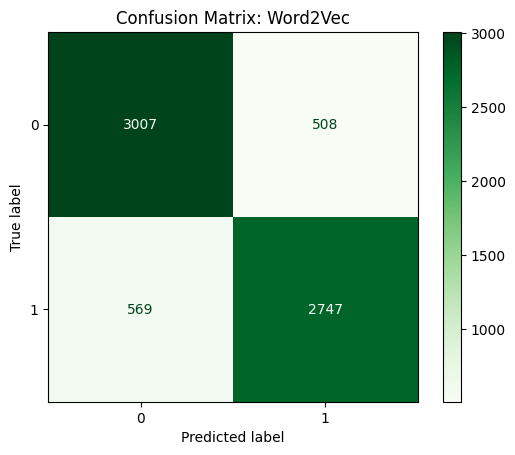

Generating final Word2Vec predictions...

 MODEL 3: Sentence Transformer (all-MiniLM-L6-v2)
Loading Transformer model and encoding sentences...


e:\Python\.venv_gpu\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\felic\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8571.52it/s]
BertModel LOAD REPORT from: sentence-tran

Transformer Estimated Accuracy: 94.04%
Transformer Estimated F1 Score: 94.04%


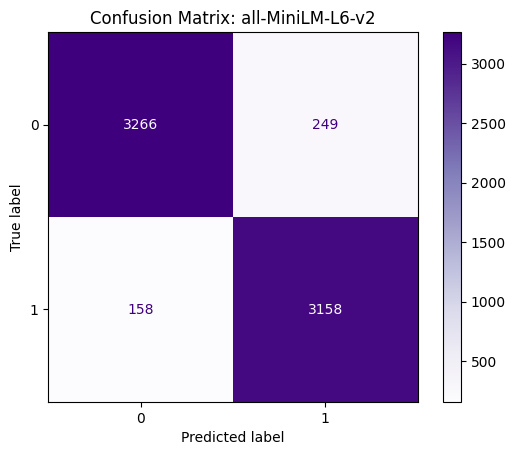

Predicting on test set using Transformer model...


Batches: 100%|██████████| 312/312 [00:03<00:00, 91.79it/s] 



Saving final test data results...

🎉 ALL DONE! Check your 'dataset' folder for the three predicted output files.


In [ ]:
import re
import csv
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.tag import pos_tag
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer

# =====================================================================
# 1. SETUP & DOWNLOADS
# =====================================================================
print("Initializing environment...")

try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
    nltk.data.find('help/tagsets')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')
    nltk.download('averaged_perceptron_tagger')

try:
    STOP_WORDS = set(stopwords.words('english'))
except LookupError:
    STOP_WORDS = {
        'a', 'an', 'and', 'are', 'as', 'at', 'be', 'been', 'but', 'by', 'for',
        'from', 'has', 'have', 'he', 'in', 'is', 'it', 'its', 'of', 'on', 'or',
        'she', 'that', 'the', 'their', 'they', 'this', 'to', 'was', 'we', 'will',
        'with', 'you', 'your', 'i', 'me', 'my', 'our', 'ours', 'them', 'his', 'her'
    }

# =====================================================================
# 2. CUSTOM TEXT PREPROCESSOR CLASSES
# =====================================================================

class BasePreprocessor:
    """Base class containing shared utility functions for text cleaning."""
    CONTRACTIONS = {
        "don't": "do not", "doesn't": "does not", "didn't": "did not",
        "can't": "cannot", "couldn't": "could not", "won't": "will not",
        "wouldn't": "would not", "isn't": "is not", "aren't": "are not",
        "wasn't": "was not", "weren't": "were not", "hasn't": "has not",
        "haven't": "have not", "hadn't": "had not", "I've": "I have",
        "you've": "you have", "we've": "we have", "they've": "they have",
        "I'm": "I am", "you're": "you are", "he's": "he is", "she's": "she is",
        "it's": "it is", "we're": "we are", "they're": "they are",
        "I'll": "I will", "you'll": "you will", "it'll": "it will"
    }

    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        contraction_keys = sorted(self.CONTRACTIONS, key=len, reverse=True)
        self._contraction_pattern = re.compile(
            r'\b(' + '|'.join(re.escape(k) for k in contraction_keys) + r')\b',
            flags=re.IGNORECASE,
        )

    def expand_contractions(self, text: str) -> str:
        def replace(match):
            matched_text = match.group(0)
            return self.CONTRACTIONS.get(matched_text, self.CONTRACTIONS.get(matched_text.lower(), matched_text))
        return self._contraction_pattern.sub(replace, text)

    def _get_wordnet_pos(self, treebank_tag: str) -> str:
        if treebank_tag.startswith('J'): return wordnet.ADJ
        elif treebank_tag.startswith('V'): return wordnet.VERB
        elif treebank_tag.startswith('N'): return wordnet.NOUN
        elif treebank_tag.startswith('R'): return wordnet.ADV
        else: return wordnet.NOUN

class TextPreprocessorTFIDF(BasePreprocessor):
    """
    Preprocessor optimized for TF-IDF. 
    Outputs a flat list of tokens (standard for Bag-of-Words).
    """
    def __init__(self, lowercase=True, remove_stopwords=True, use_lemmatize=True, min_token_len=2):
        super().__init__()
        self.lowercase = lowercase
        self.remove_stopwords = remove_stopwords
        self.use_lemmatize = use_lemmatize
        self.min_token_len = min_token_len
        self.stemmer = PorterStemmer()

    def remove_noise(self, text: str) -> str:
        text = re.sub(r'https?://\S+|www\.\S+', '', text) 
        text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text) 
        text = re.sub(r'[@#]\w+', '', text) 
        text = re.sub(r'[^a-zA-Z\s]', ' ', text) 
        text = re.sub(r'\s+', ' ', text).strip() 
        return text

    def process(self, text: str) -> list:
        text = self.expand_contractions(text)
        text = self.remove_noise(text)
        if self.lowercase: text = text.lower()
        
        tokens = word_tokenize(text)
        tagged_tokens = pos_tag(tokens)
        
        if self.use_lemmatize:
            tokens = [self.lemmatizer.lemmatize(t, pos=self._get_wordnet_pos(tag)) for t, tag in tagged_tokens]
        else:
            tokens = [self.stemmer.stem(t) for t, _ in tagged_tokens]
            
        if self.remove_stopwords:
            tokens = [t for t in tokens if t not in STOP_WORDS]
            
        return [t for t in tokens if len(t) >= self.min_token_len]

class TextPreprocessorWord2Vec(BasePreprocessor):
    """
    Specialized Preprocessor for Word2Vec Embeddings.
    Focuses on sentence structure preservation and returns a list of lists of tokens.
    """
    def __init__(self, lowercase=True, remove_stopwords=True, min_token_len=2):
        super().__init__()
        self.lowercase = lowercase
        self.remove_stopwords = remove_stopwords
        self.min_token_len = min_token_len

    def clean_text(self, text: str) -> str:
        text = re.sub(r'https?://\S+|www\.\S+', '', text) 
        text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text) 
        text = re.sub(r'[@#]\w+', '', text) 
        text = re.sub(r'[^a-zA-Z\s\.\!\?]', ' ', text) 
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def process_sentence(self, sentence_str: str) -> list:
        if self.lowercase: sentence_str = sentence_str.lower()
        tokens = word_tokenize(sentence_str)
        tagged_tokens = pos_tag(tokens)
        
        clean_tokens = []
        for word, tag in tagged_tokens:
            if not re.match(r'[a-zA-Z]', word): continue
            lemma = self.lemmatizer.lemmatize(word, pos=self._get_wordnet_pos(tag))
            if self.remove_stopwords and lemma in STOP_WORDS: continue
            if len(lemma) < self.min_token_len: continue
            clean_tokens.append(lemma)
        return clean_tokens

    def process_corpus(self, text: str) -> list:
        text = self.expand_contractions(text)
        text = self.clean_text(text)
        sentences = sent_tokenize(text)
        
        corpus_tokens = []
        for sent in sentences:
            processed_sent = self.process_sentence(sent)
            if len(processed_sent) >= 2:
                corpus_tokens.append(processed_sent)
        return corpus_tokens

class TextPreprocessorTransformer(BasePreprocessor):
    """
    Preprocessor for Sentence Transformers.
    Transformers are context-aware, so we keep most of the sentence structure.
    We only expand contractions and remove extreme noise like URLs.
    """
    def __init__(self, lowercase=False):
        super().__init__()
        self.lowercase = lowercase

    def clean_text(self, text: str) -> str:
        # Remove URLs and emails but keep punctuation and casing for context
        text = re.sub(r'https?://\S+|www\.\S+', '', text) 
        text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text) 
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def process(self, text: str) -> str:
        text = self.expand_contractions(text)
        text = self.clean_text(text)
        if self.lowercase: 
            text = text.lower()
        return text

# =====================================================================
# 3. DATA LOADING & PREPARATION
# =====================================================================
print("Loading datasets...")
try:
    df_training = pd.read_csv("dataset/training_data.csv", header=None)
    df_test = pd.read_csv("dataset/testing_data.csv", header=None)
except FileNotFoundError:
    print("Files not found. Please ensure 'dataset/training_data.csv' exists.")
    df_training = pd.DataFrame({0: ["1 I love learning NLP", "2 The economy is shifting"]})
    df_test = pd.DataFrame({0: ["1 I like coding", "2 The stock market"]})

df_training.rename(columns={df_training.columns[0]: "news_column"}, inplace=True)
df_test.rename(columns={df_test.columns[0]: "news_column"}, inplace=True)

# Extract labels
df_training['label'] = df_training['news_column'].str[0].astype(int)

# Initialize Preprocessors
preprocessortfidf = TextPreprocessorTFIDF()
preprocessorw2v = TextPreprocessorWord2Vec()
preprocessortrans = TextPreprocessorTransformer()

# Apply TF-IDF Preprocessing
print("Cleaning text for TF-IDF...")
df_training['tokens_tfidf'] = df_training['news_column'].apply(lambda x: preprocessortfidf.process(str(x)))
df_training['cleaned_text_tfidf'] = df_training['tokens_tfidf'].apply(lambda x: " ".join(x))
df_test['cleaned_text_tfidf'] = df_test['news_column'].apply(lambda x: " ".join(preprocessortfidf.process(str(x))))

# Apply Word2Vec Preprocessing
print("Cleaning text for Word2Vec...")
df_training['tokens_w2v'] = df_training['news_column'].apply(lambda x: preprocessorw2v.process_corpus(str(x)))
df_training['tokens_w2v_flat'] = df_training['tokens_w2v'].apply(lambda x: [item for sublist in x for item in sublist])
df_test['tokens_w2v_flat'] = df_test['news_column'].apply(lambda x: [item for sublist in preprocessorw2v.process_corpus(str(x)) for item in sublist])

# Apply Transformer Preprocessing (Preserves context)
print("Cleaning text for Sentence Transformers...")
df_training['cleaned_text_trans'] = df_training['news_column'].apply(lambda x: preprocessortrans.process(str(x)[1:]))
df_test['cleaned_text_trans'] = df_test['news_column'].apply(lambda x: preprocessortrans.process(str(x)[1:]))

# =====================================================================
# 4. DATA VISUALIZATION (Shared)
# =====================================================================
print("\nGenerating Word Frequency Bar Charts...")
all_processed_words = [word for tokens_list in df_training['tokens_tfidf'] for word in tokens_list]
top_20_processed = Counter(all_processed_words).most_common(20)
if top_20_processed:
    processed_words, processed_counts = zip(*top_20_processed)
    plt.figure(figsize=(10, 6))
    plt.barh(processed_words, processed_counts)
    plt.title('Top 20 Processed Tokens (TF-IDF Prep)')
    plt.gca().invert_yaxis()
    plt.show()
    top_20_words_list = list(processed_words)

# =====================================================================
# 5. MODEL 1: TF-IDF + LinearSVC
# =====================================================================
print("\n" + "="*50)
print(" MODEL 1: TF-IDF + LinearSVC")
print("="*50)

X_train_tf, X_val_tf, y_train_tf, y_val_tf = train_test_split(
    df_training['cleaned_text_tfidf'], df_training['label'], test_size=0.2, random_state=42, stratify=df_training['label']
)

tfidf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=25000, ngram_range=(1, 2))),
    ('classifier', LinearSVC(random_state=42, max_iter=2000)) 
])

tfidf_pipeline.fit(X_train_tf, y_train_tf)
y_pred_tf = tfidf_pipeline.predict(X_val_tf)

print(f"TF-IDF Estimated Accuracy: {accuracy_score(y_val_tf, y_pred_tf) * 100:.2f}%")
print(f"TF-IDF Estimated F1 Score: {f1_score(y_val_tf, y_pred_tf, average='weighted') * 100:.2f}%")

cm_tf = confusion_matrix(y_val_tf, y_pred_tf)
ConfusionMatrixDisplay(confusion_matrix=cm_tf).plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: TF-IDF')
plt.show()

# Final Prediction for TF-IDF
print("Generating final TF-IDF predictions...")
tfidf_pipeline.fit(df_training['cleaned_text_tfidf'], df_training['label'])
predictions_tfidf = tfidf_pipeline.predict(df_test['cleaned_text_tfidf'])

# =====================================================================
# 6. MODEL 2: Word2Vec + LinearSVC
# =====================================================================
print("\n" + "="*50)
print(" MODEL 2: Word2Vec + LinearSVC")
print("="*50)

all_w2v_sentences = [sent for doc in df_training['tokens_w2v'] for sent in doc]
w2v_model = Word2Vec(sentences=all_w2v_sentences, vector_size=100, window=5, min_count=1, workers=4)

def get_document_vector(tokens, model):
    valid_tokens = [word for word in tokens if word in model.wv.key_to_index]
    if not valid_tokens: return np.zeros(model.vector_size)
    return np.mean(model.wv[valid_tokens], axis=0)

X_w2v_all = np.array([get_document_vector(t, w2v_model) for t in df_training['tokens_w2v_flat']])
y_w2v_all = df_training['label']

X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(
    X_w2v_all, y_w2v_all, test_size=0.2, random_state=42, stratify=y_w2v_all
)

w2v_classifier = LinearSVC(random_state=42, max_iter=3000)
w2v_classifier.fit(X_train_w2v, y_train_w2v)
y_pred_w2v = w2v_classifier.predict(X_val_w2v)

print(f"Word2Vec Estimated Accuracy: {accuracy_score(y_val_w2v, y_pred_w2v) * 100:.2f}%")
print(f"Word2Vec Estimated F1 Score: {f1_score(y_val_w2v, y_pred_w2v, average='weighted') * 100:.2f}%")

cm_w2v = confusion_matrix(y_val_w2v, y_pred_w2v)
ConfusionMatrixDisplay(confusion_matrix=cm_w2v).plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix: Word2Vec')
plt.show()

# Final Prediction for Word2Vec
print("Generating final Word2Vec predictions...")
w2v_classifier.fit(X_w2v_all, y_w2v_all)
X_test_w2v = np.array([get_document_vector(t, w2v_model) for t in df_test['tokens_w2v_flat']])
predictions_w2v = w2v_classifier.predict(X_test_w2v)

# =====================================================================
# 7. MODEL 3: Sentence Transformer (all-MiniLM-L6-v2) + LinearSVC
# =====================================================================
print("\n" + "="*50)
print(" MODEL 3: Sentence Transformer (all-MiniLM-L6-v2)")
print("="*50)

print("Loading Transformer model and encoding sentences...")
st_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for the full training set
X_st_all = st_model.encode(df_training['cleaned_text_trans'].tolist(), show_progress_bar=True)
y_st_all = df_training['label']

X_train_st, X_val_st, y_train_st, y_val_st = train_test_split(
    X_st_all, y_st_all, test_size=0.2, random_state=42, stratify=y_st_all
)

st_classifier = LinearSVC(random_state=42, max_iter=3000)
st_classifier.fit(X_train_st, y_train_st)
y_pred_st = st_classifier.predict(X_val_st)

print(f"Transformer Estimated Accuracy: {accuracy_score(y_val_st, y_pred_st) * 100:.2f}%")
print(f"Transformer Estimated F1 Score: {f1_score(y_val_st, y_pred_st, average='weighted') * 100:.2f}%")

# --- Transformer Confusion Matrix ---
cm_st = confusion_matrix(y_val_st, y_pred_st)
ConfusionMatrixDisplay(confusion_matrix=cm_st).plot(cmap=plt.cm.Purples)
plt.title('Confusion Matrix: all-MiniLM-L6-v2')
plt.show()

# Final Prediction for Transformer
print("Predicting on test set using Transformer model...")
X_test_st = st_model.encode(df_test['cleaned_text_trans'].tolist(), show_progress_bar=True)
st_classifier.fit(X_st_all, y_st_all) # Retrain on all training data
predictions_st = st_classifier.predict(X_test_st)

# =====================================================================
# 8. SAVING FINAL RESULTS FOR TEST DATA
# =====================================================================
print("\nSaving final test data results...")

# Reconstruct text with predicted label (assuming news_column starts with original label/space)
df_test['final_tfidf'] = predictions_tfidf.astype(str) + df_test['news_column'].str[1:]
df_test['final_w2v'] = predictions_w2v.astype(str) + df_test['news_column'].str[1:]
df_test['final_transformer'] = predictions_st.astype(str) + df_test['news_column'].str[1:]

df_test['final_tfidf'].to_csv("dataset/testing_data_predicted_tfidf.csv", index=False, header=False, quoting=csv.QUOTE_NONE, escapechar='\\')
df_test['final_w2v'].to_csv("dataset/testing_data_predicted_w2v.csv", index=False, header=False, quoting=csv.QUOTE_NONE, escapechar='\\')
df_test['final_transformer'].to_csv("dataset/testing_data_predicted_transformer.csv", index=False, header=False, quoting=csv.QUOTE_NONE, escapechar='\\')

print("\n🎉 ALL DONE! Check your 'dataset' folder for the three predicted output files.")